# Cuaderno 3 — PCA, K-Means y análisis por sección censal

Este cuaderno continúa el análisis del mercado residencial de Barcelona introduciendo dos técnicas de **aprendizaje no supervisado**:

| Técnica | ¿Para qué sirve? |
|---|---|
| **PCA** (*Análisis de Componentes Principales*) | Reducir varias variables correlacionadas a un índice sintético |
| **K-Means** | Agrupar las observaciones en clústeres según sus características |

Además, cruzaremos los resultados del modelo XGBoost (Cuaderno 2) con las **secciones censales** para entender qué zonas concentran más errores del modelo.

---

## 🔧 Configuración inicial

Estas celdas instalan las librerías necesarias, cargan los datos originales y los resultados del Cuaderno 2 desde Google Drive.


In [1]:
# ─── Librerías ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# Estadística y machine learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway

# Rotación Varimax
!pip install -q factor_analyzer
from factor_analyzer.rotator import Rotator

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ MODIFICA AQUÍ — Rutas a tus archivos en Google Drive
RUTA_DATOS_RESIDUOS  = "/content/drive/MyDrive/srgvua/datos_con_residuos.gpkg"   # Salida del Cuaderno 2
RUTA_SECCIONES       = "https://github.com/jose-rojasquiroz/jose-rojasquiroz.github.io/raw/main/teaching/srgvua_25_26/data/secciones_censales_ajustadas.gpkg"
RUTA_OFERTAS         = "https://github.com/jose-rojasquiroz/jose-rojasquiroz.github.io/raw/main/teaching/srgvua_25_26/data/ofertas-bcn_mun-viv_ven.gpkg"

# ─── Cargar datos ─────────────────────────────────────────────────────────────
print("⏳ Cargando datos con residuos (Cuaderno 2)...")
gdf_res = gpd.read_file(RUTA_DATOS_RESIDUOS)
print(f"   ✅ {gdf_res.shape[0]:,} filas × {gdf_res.shape[1]} columnas   (CRS: {gdf_res.crs})")

print("⏳ Cargando secciones censales ajustadas...")
secciones = gpd.read_file(RUTA_SECCIONES)
print(f"   ✅ {secciones.shape[0]:,} secciones   (CRS: {secciones.crs})")

print("⏳ Cargando dataset original de ofertas...")
gdf_ofertas = gpd.read_file(RUTA_OFERTAS)
print(f"   ✅ {gdf_ofertas.shape[0]:,} filas × {gdf_ofertas.shape[1]} columnas   (CRS: {gdf_ofertas.crs})")

# Asegurar CRS común para los joins espaciales
CRS_REF = secciones.crs
if gdf_res.crs != CRS_REF:
    gdf_res = gdf_res.to_crs(CRS_REF)
if gdf_ofertas.crs != CRS_REF:
    gdf_ofertas = gdf_ofertas.to_crs(CRS_REF)

print(f"\n✅ Todos los datos en CRS: {CRS_REF}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Cargando datos con residuos (Cuaderno 2)...
   ✅ 9,168 filas × 12 columnas   (CRS: EPSG:25831)
⏳ Cargando secciones censales ajustadas...
   ✅ 324 secciones   (CRS: EPSG:25831)
⏳ Cargando dataset original de ofertas...
   ✅ 9,168 filas × 48 columnas   (CRS: EPSG:25831)

✅ Todos los datos en CRS: EPSG:25831


In [3]:
print(secciones.columns.tolist())

['tract_id_adjusted', 'composite_vulnerability', 'geometry']


### 🛠️ Funciones auxiliares

Las funciones de este cuaderno están centralizadas aquí. No es necesario modificarlas, pero puedes leerlas para entender cómo funcionan.


In [4]:
# ─── Funciones auxiliares ────────────────────────────────────────────────────

def mapa_secciones(secciones_df, col_valor, titulo,
                   col_n='n_ofertas', min_n=5,
                   cmap='RdYlGn', label_leyenda='Valor', fmt='%.0f%%'):
    """
    Mapa coroplético de secciones censales.
    Las secciones con menos de min_n ofertas se muestran en gris.
    """
    con_datos = secciones_df[secciones_df[col_n] >= min_n].copy()
    sin_datos = secciones_df[secciones_df[col_n] < min_n].copy()

    fig, ax = plt.subplots(figsize=(11, 10))
    if len(sin_datos) > 0:
        sin_datos.plot(ax=ax, color='#eeeeee', linewidth=0.3, edgecolor='#cccccc')
    con_datos.plot(
        column=col_valor, cmap=cmap, ax=ax,
        linewidth=0.3, edgecolor='#bbbbbb', legend=True,
        legend_kwds={'label': label_leyenda, 'shrink': 0.65, 'format': fmt}
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.axis('off')
    if len(sin_datos) > 0:
        ax.annotate(
            f'Gris: secciones con < {min_n} ofertas ({len(sin_datos)} secciones)',
            xy=(0.01, 0.01), xycoords='axes fraction', fontsize=8, color='#777777'
        )
    plt.tight_layout()
    plt.show()

def scree_plot_pca(varianza_individual, varianza_acumulada):
    """Scree plot con barras de varianza individual y línea de varianza acumulada."""
    componentes = [f'CP{i+1}' for i in range(len(varianza_individual))]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(componentes, varianza_individual, color='steelblue', alpha=0.8, label='Individual')
    ax.plot(componentes, varianza_acumulada, 'o-', color='darkred', linewidth=2, label='Acumulada')
    ax.axhline(80, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='80%')
    ax.set_ylabel('Varianza explicada (%)', fontsize=11)
    ax.set_title('Scree plot — varianza por componente', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def mapa_clusters_kmeans(gdf_km, col_cluster_ord, mapa_etiqueta,
                          precio_medio_por_cluster, k_optimo, vars_kmeans):
    """
    Mapa de puntos coloreados por nivel de clúster K-Means.
    Escala RdYlGn: rojo = peores condiciones de mercado, verde = mejores.
    """
    paleta  = plt.cm.RdYlGn(np.linspace(0.1, 0.9, k_optimo))
    colores = {nivel: paleta[nivel - 1] for nivel in range(1, k_optimo + 1)}

    fig, ax = plt.subplots(figsize=(11, 10))
    for nivel in range(1, k_optimo + 1):
        gdf_km[gdf_km[col_cluster_ord] == nivel].plot(
            ax=ax, color=colores[nivel], markersize=10, alpha=0.5, linewidth=0
        )

    ax.set_title(
        f'Segmentación K-Means (k={k_optimo}) — variables: {", ".join(vars_kmeans)}\n'
        'Verde oscuro = mejores condiciones de mercado (mayor precio/m²)',
        fontsize=12, fontweight='bold'
    )
    ax.axis('off')

    patches_km = [
        mpatches.Patch(
            color=colores[nivel],
            label=(
                f'Nivel {nivel} — '
                f'{precio_medio_por_cluster[[k for k, v in mapa_etiqueta.items() if v == nivel][0]]:,.0f} €/m²'
                f'  (n={len(gdf_km[gdf_km[col_cluster_ord] == nivel]):,})'
            )
        )
        for nivel in range(1, k_optimo + 1)
    ]
    ax.legend(handles=patches_km, loc='upper left', fontsize=9, framealpha=0.9,
              title='cluster_buenas_condiciones', title_fontsize=9)
    plt.tight_layout()
    plt.show()

print("✅ Funciones auxiliares definidas: mapa_secciones | scree_plot_pca | mapa_clusters_kmeans")

✅ Funciones auxiliares definidas: mapa_secciones | scree_plot_pca | mapa_clusters_kmeans


---
## Paso 1 — Porcentaje de residuos positivos del XGBoost por sección censal

Un residuo positivo significa que el modelo **subestimó** el precio real (el piso costó más de lo que el modelo predijo). Un porcentaje alto de residuos positivos en una zona indica que el modelo no captura bien la prima de precio de esa área.

El proceso es:
1. Unir espacialmente cada oferta con su sección censal (*spatial join*).
2. Por cada sección, calcular qué porcentaje de sus residuos son positivos.
3. Cartografiar el resultado.


In [5]:
# ─── Join espacial: oferta → sección censal ───────────────────────────────────

# Trabajamos sólo con filas que tienen residuo XGBoost calculado
gdf_con_res = gdf_res[gdf_res['residuos_xgb'].notna()].copy()

# Spatial join: cada punto hereda el identificador de la sección que lo contiene
joined = gpd.sjoin(
    gdf_con_res[['geometry', 'residuos_xgb']],
    secciones[['geometry', 'tract_id_adjusted']],   # tract_id_adjusted = código único de sección censal
    how='left',
    predicate='within'
)

# ─── Calcular % de residuos positivos por sección ────────────────────────────

def pct_positivos(serie):
    """Porcentaje de valores estrictamente positivos."""
    return (serie > 0).sum() / len(serie) * 100

resumen_sec = (
    joined.groupby('tract_id_adjusted')['residuos_xgb']
    .agg(
        n_ofertas='count',
        pct_res_positivo=pct_positivos,
        residuo_medio='mean'
    )
    .reset_index()
)

print(f"✅ Estadísticas por sección censal calculadas ({len(resumen_sec):,} secciones con datos)")
print(f"\n   Distribución del % de residuos positivos:")
print(resumen_sec['pct_res_positivo'].describe().round(2).to_string())


✅ Estadísticas por sección censal calculadas (324 secciones con datos)

   Distribución del % de residuos positivos:
count    324.00
mean      48.40
std       12.69
min       15.38
25%       39.19
50%       48.15
75%       56.79
max       90.91


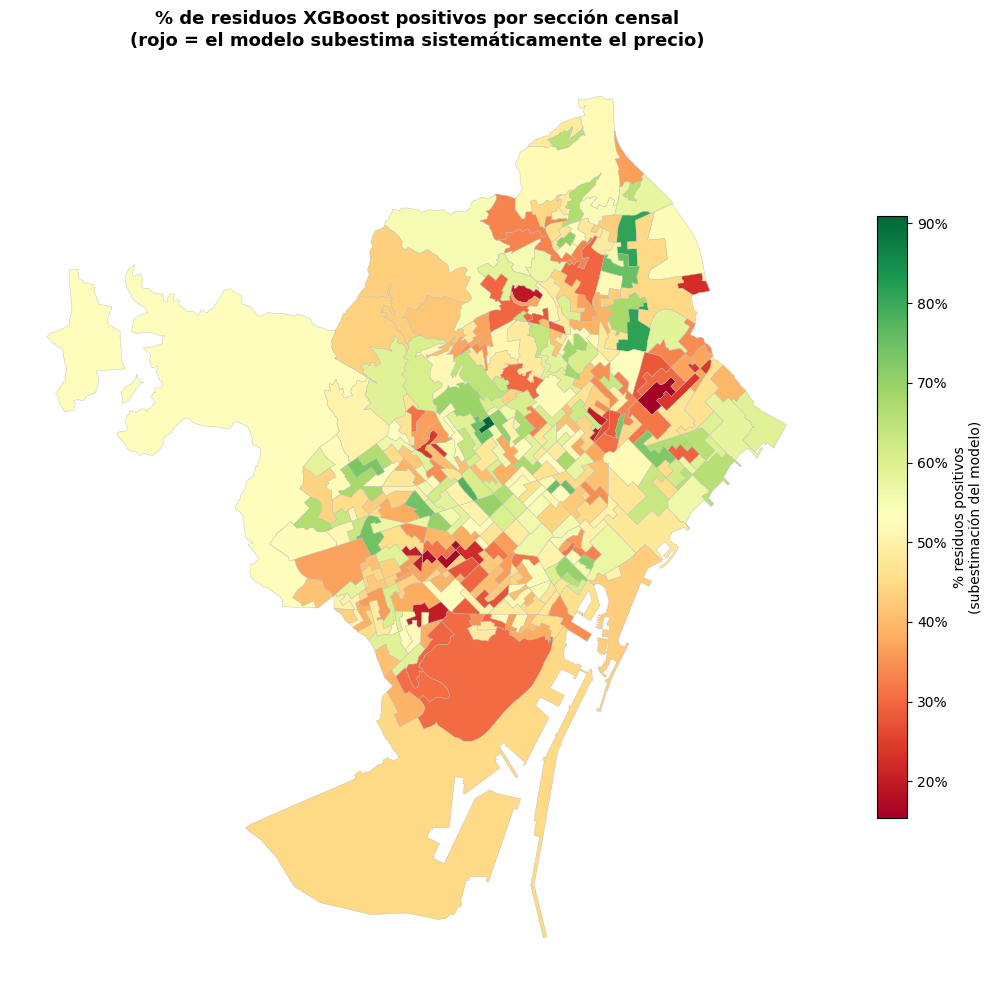

In [6]:
# ─── Unir estadísticas al GeoDataFrame de secciones y mapear ─────────────────

secciones_plot = secciones.merge(resumen_sec, on='tract_id_adjusted', how='left')

mapa_secciones(
    secciones_plot,
    col_valor='pct_res_positivo',
    titulo=(
        '% de residuos XGBoost positivos por sección censal\n'
        '(rojo = el modelo subestima sistemáticamente el precio)'
    ),
    cmap='RdYlGn',
    label_leyenda='% residuos positivos\n(subestimación del modelo)'
)


---
## Paso 2 — PCA con rotación Varimax: índice de centralidad

El **Análisis de Componentes Principales (PCA)** transforma un conjunto de variables correlacionadas en nuevas variables no correlacionadas (*componentes*). Cada componente es una combinación lineal de las originales y captura una parte de la varianza total.

La **rotación Varimax** mejora la interpretabilidad: maximiza la diferencia entre las cargas de cada componente, haciendo que cada variable original "cargue" fuertemente en sólo uno o pocos componentes.

Aquí aplicamos PCA a:
- `distancia_plaza_cat` — distancia a la Plaza de Cataluña
- `distancia_fr_macia` — distancia a la Plaza de Francesc Macià

Ambas son medidas de **distancia a centralidades urbanas**, por lo que esperamos que el primer componente represente un **índice de centralidad general**.

> **Nota:** Usamos el dataset original `ofertas-bcn_mun-viv_ven.gpkg` porque necesitamos todas las observaciones, no sólo las que tienen residuos calculados.


In [7]:
# ✏️ MODIFICA AQUÍ — Variables para el PCA
VARS_PCA = ['distancia_plaza_cat', 'distancia_fr_macia']

# ─── Preparar datos: eliminar nulos en las variables PCA ──────────────────────
gdf_pca = gdf_ofertas[['geometry'] + VARS_PCA].dropna().copy()
gdf_pca = gdf_pca.reset_index(drop=True)

print(f"✅ Observaciones para PCA: {len(gdf_pca):,} (de {len(gdf_ofertas):,} totales)")
print(f"   Variables: {VARS_PCA}")

# ─── Estandarizar (Z-scores): el PCA es sensible a la escala ─────────────────
scaler_pca = StandardScaler()
X_pca_std  = scaler_pca.fit_transform(gdf_pca[VARS_PCA])

# ─── Ajustar PCA con todos los componentes posibles ──────────────────────────
pca = PCA(n_components=len(VARS_PCA))
pca.fit(X_pca_std)

print(f"\n✅ PCA ajustado con {pca.n_components_} componentes")

✅ Observaciones para PCA: 9,168 (de 9,168 totales)
   Variables: ['distancia_plaza_cat', 'distancia_fr_macia']

✅ PCA ajustado con 2 componentes


### Varianza explicada por componente


In [18]:
# ─── Tabla de varianza explicada ─────────────────────────────────────────────

varianza_individual = pca.explained_variance_ratio_ * 100
varianza_acumulada  = np.cumsum(varianza_individual)

tabla_varianza = pd.DataFrame({
    'Componente':             [f'CP{i+1}' for i in range(len(varianza_individual))],
    'Varianza explicada (%)': varianza_individual.round(2),
    'Varianza acumulada (%)': varianza_acumulada.round(2),
})

print("=" * 50)
print("VARIANZA EXPLICADA POR COMPONENTE")
print("=" * 50)
print(tabla_varianza.to_string(index=False))
print("=" * 50)

VARIANZA EXPLICADA POR COMPONENTE
Componente  Varianza explicada (%)  Varianza acumulada (%)
       CP1                   86.81                   86.81
       CP2                   13.19                  100.00


### Cargas de los componentes (con rotación Varimax)

Las **cargas** (*loadings*) indican la correlación entre cada variable original y cada componente. Valores cercanos a ±1 implican que esa variable tiene mucho peso en ese componente.

La **rotación Varimax** redistribuye las cargas para que sean lo más polarizadas posible (próximas a 0 o a ±1), facilitando la interpretación.


In [9]:
# ─── Cargas sin rotar ─────────────────────────────────────────────────────────
loadings_raw = pd.DataFrame(
    pca.components_.T,                        # Filas = variables, columnas = componentes
    index=VARS_PCA,
    columns=[f'CP{i+1}' for i in range(pca.n_components_)]
)

# ─── Rotación Varimax ─────────────────────────────────────────────────────────
# (con sólo 2 variables la rotación es ilustrativa; con más variables es muy útil)
rotator = Rotator(method='varimax')
loadings_rot = pd.DataFrame(
    rotator.fit_transform(loadings_raw.values),
    index=VARS_PCA,
    columns=[f'CP{i+1} (rot.)' for i in range(pca.n_components_)]
)

print("\n" + "="*55)
print("CARGAS — Con rotación Varimax")
print("="*55)
print(loadings_rot.round(4).to_string())
print("="*55)
print("\n💡 Interpretación: valores cercanos a ±1 indican que esa")
print("   variable define principalmente ese componente.")


CARGAS — Con rotación Varimax
                     CP1 (rot.)  CP2 (rot.)
distancia_plaza_cat      0.7071      0.7071
distancia_fr_macia       0.7071     -0.7071

💡 Interpretación: valores cercanos a ±1 indican que esa
   variable define principalmente ese componente.


### Agregar el primer componente como `indice_centralidad`

El primer componente captura la mayor parte de la variabilidad compartida entre ambas distancias. Lo interpretamos como un **índice de centralidad**: valores altos indican mayor lejanía de ambas centralidades (menor centralidad), valores bajos indican mayor proximidad (mayor centralidad).

> Si el signo del índice resultase contraintuitivo (valores altos = más central), se puede invertir multiplicando por −1.


✅ 'indice_centralidad' añadido al dataset principal
   Observaciones con valor: 9,168

   Estadísticas descriptivas:
count    9168.0000
mean        0.0000
std         1.3177
min        -1.5832
25%        -1.0113
50%        -0.4283
75%         0.7643
max         4.7921


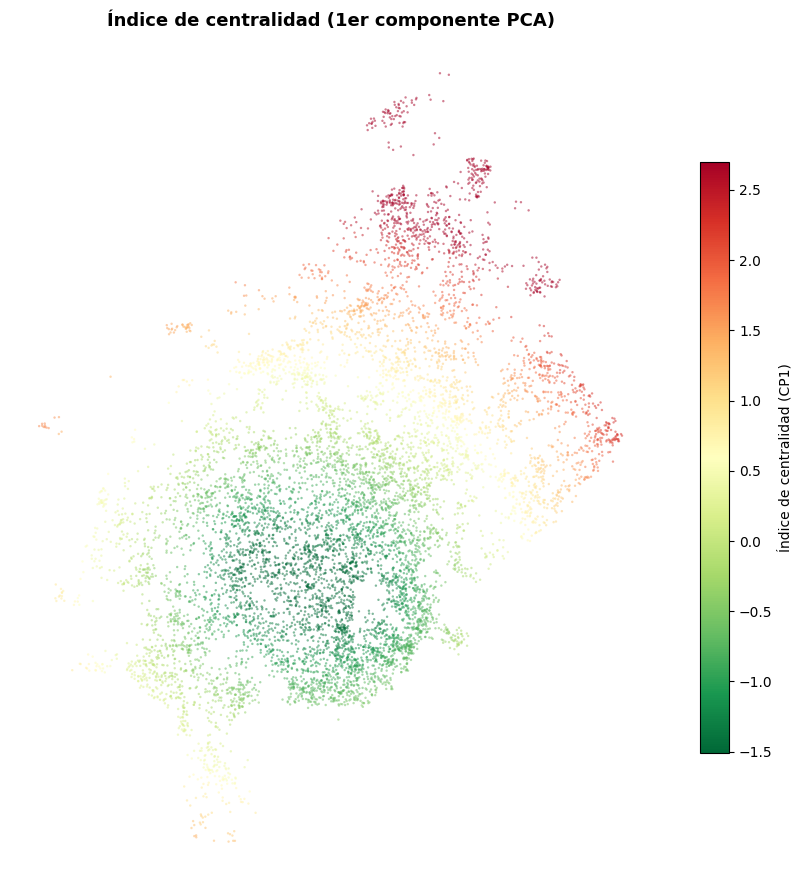

In [10]:
# ─── Proyectar los datos sobre todos los componentes ─────────────────────────
scores = pca.transform(X_pca_std)   # shape: (n_obs, n_componentes)

# El primer componente (CP1) → índice de centralidad
gdf_pca['indice_centralidad'] = scores[:, 0]

# ✏️ Opcional — Si CP1 tiene signo inverso al esperado (mayor valor = más central),
# descomenta la siguiente línea para invertirlo:
# gdf_pca['indice_centralidad'] = -gdf_pca['indice_centralidad']

# ─── Propagarlo al dataset completo de ofertas ────────────────────────────────
gdf_ofertas = gdf_ofertas.merge(
    gdf_pca[['indice_centralidad']],
    left_index=True,
    right_index=True,
    how='left'
)

print(f"✅ 'indice_centralidad' añadido al dataset principal")
print(f"   Observaciones con valor: {gdf_ofertas['indice_centralidad'].notna().sum():,}")
print(f"\n   Estadísticas descriptivas:")
print(gdf_ofertas['indice_centralidad'].describe().round(4).to_string())

# ─── Mapa del índice de centralidad ───────────────────────────────────────────
gdf_ic = gdf_ofertas[gdf_ofertas['indice_centralidad'].notna()].copy()
vmin_ic = gdf_ic['indice_centralidad'].quantile(0.05)
vmax_ic = gdf_ic['indice_centralidad'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 9))
gdf_ic.plot(
    column='indice_centralidad',
    cmap='RdYlGn_r',   # Rojo = alta centralidad (CP1 bajo = cerca de centros), Verde = periferia
    ax=ax,
    alpha=0.5,
    markersize=3,
    linewidth=0,
    legend=True,
    vmin=vmin_ic, vmax=vmax_ic,
    legend_kwds={'label': 'Índice de centralidad (CP1)', 'shrink': 0.7}
)
ax.set_title('Índice de centralidad (1er componente PCA)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


---
## Paso 3 — K-Means: segmentación del mercado

**K-Means** agrupa las observaciones en *k* clústeres de forma que los puntos dentro de cada grupo sean lo más parecidos posible entre sí, y lo más distintos posible entre grupos.

Variables utilizadas:
- `precio_unitario` — precio por m² (proxy de valor de mercado)
- `rm_h` — número de habitaciones (proxy de tamaño/tipología)
- `calidad_construccion` — calidad constructiva

### Normalización con Z-scores

Antes de aplicar K-Means es **imprescindible normalizar** porque el algoritmo mide distancias euclídeas. Sin normalizar, una variable con valores grandes (ej. precio €/m²) dominaría sobre las demás.


In [11]:
# ✏️ MODIFICA AQUÍ — Variables para el K-Means
VARS_KMEANS = ['precio_unitario', 'rm_h', 'calidad_construccion']

# ─── Eliminar nulos y preparar matriz ────────────────────────────────────────
gdf_km = gdf_ofertas[['geometry'] + VARS_KMEANS].dropna().copy()
gdf_km = gdf_km.reset_index(drop=True)

print(f"✅ Observaciones para K-Means: {len(gdf_km):,} (de {len(gdf_ofertas):,} totales)")

# ─── Normalización Z-scores ───────────────────────────────────────────────────
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(gdf_km[VARS_KMEANS])

# Tabla comparativa antes/después para que los estudiantes vean el efecto
df_antes  = gdf_km[VARS_KMEANS].describe().loc[['mean','std','min','max']].round(3)
df_despues = pd.DataFrame(X_km, columns=VARS_KMEANS).describe().loc[['mean','std','min','max']].round(3)

print("\n── Antes de normalizar ──")
print(df_antes.to_string())
print("\n── Después de normalizar (Z-scores) ──")
print(df_despues.to_string())
print("\n💡 Tras la normalización: media ≈ 0, desv. típica ≈ 1 en todas las variables")


✅ Observaciones para K-Means: 9,168 (de 9,168 totales)

── Antes de normalizar ──
      precio_unitario       rm_h  calidad_construccion
mean         4790.314  45110.325                 3.878
std          2058.628  13861.285                 1.175
min           250.000  25785.293                 1.000
max         23944.444  98221.000                 7.000

── Después de normalizar (Z-scores) ──
      precio_unitario   rm_h  calidad_construccion
mean           -0.000 -0.000                -0.000
std             1.000  1.000                 1.000
min            -2.206 -1.394                -2.450
max             9.305  3.832                 2.657

💡 Tras la normalización: media ≈ 0, desv. típica ≈ 1 en todas las variables


### Método del codo (*Elbow method*)

El **método del codo** ayuda a elegir el número óptimo de clústeres *k*. Para cada valor de *k*, calcula la **inercia** (suma de distancias al cuadrado de cada punto al centroide de su clúster). A medida que *k* aumenta, la inercia disminuye, pero a partir de cierto punto el beneficio marginal es pequeño — ese punto de inflexión es el *codo*.


⏳ Calculando inercia y silhouette para k = 2 a 10...
   k= 2  inercia=14,767  silhouette=0.4257
   k= 3  inercia=11,058  silhouette=0.3287
   k= 4  inercia=9,222  silhouette=0.3419
   k= 5  inercia=7,689  silhouette=0.3092
   k= 6  inercia=6,513  silhouette=0.3264
   k= 7  inercia=5,909  silhouette=0.3206
   k= 8  inercia=5,360  silhouette=0.3179
   k= 9  inercia=4,883  silhouette=0.3038
   k=10  inercia=4,495  silhouette=0.3009


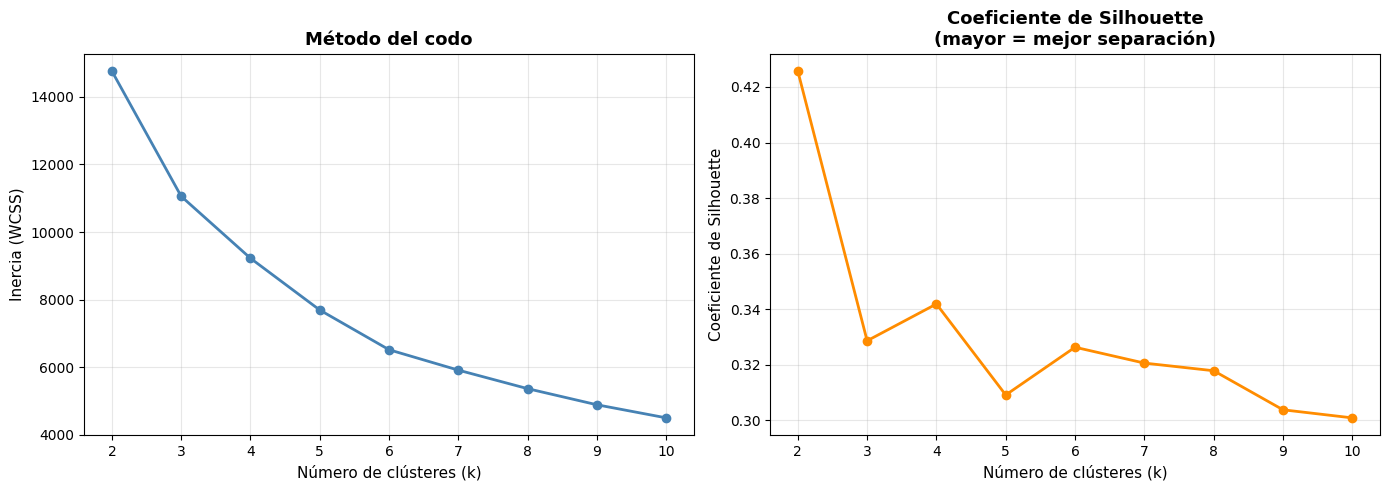

In [12]:
# ✏️ MODIFICA AQUÍ — Rango de k a explorar
K_MIN = 2
K_MAX = 10

# ─── Calcular inercia y silhouette para cada k ───────────────────────────────
inercias    = []
silhouettes = []
k_rango     = range(K_MIN, K_MAX + 1)

print(f"⏳ Calculando inercia y silhouette para k = {K_MIN} a {K_MAX}...")
for k in k_rango:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = km.fit_predict(X_km)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, etiquetas, sample_size=5000, random_state=42))
    print(f"   k={k:2d}  inercia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

# ─── Gráficos ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Codo
axes[0].plot(list(k_rango), inercias, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de clústeres (k)', fontsize=11)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=11)
axes[0].set_title('Método del codo', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(k_rango), silhouettes, 'o-', color='darkorange', linewidth=2)
axes[1].set_xlabel('Número de clústeres (k)', fontsize=11)
axes[1].set_ylabel('Coeficiente de Silhouette', fontsize=11)
axes[1].set_title('Coeficiente de Silhouette\n(mayor = mejor separación)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Seleccionar el número óptimo de clústeres y entrenar el modelo final


In [13]:
# ✏️ MODIFICA AQUÍ — Elige k según el gráfico del codo (donde la curva "dobla")
K_OPTIMO = 4

# ─── Modelo K-Means final ─────────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
gdf_km['cluster'] = km_final.fit_predict(X_km)

print(f"✅ K-Means entrenado con k = {K_OPTIMO}")
print(f"\n   Distribución de observaciones por clúster:")
print(gdf_km['cluster'].value_counts().sort_index().to_string())

✅ K-Means entrenado con k = 4

   Distribución de observaciones por clúster:
cluster
0    4127
1     886
2    3184
3     971


### Precio unitario medio por clúster

Para interpretar qué representa cada clúster, calculamos el precio medio por m² en cada uno y los ordenamos de menor a mayor precio.


In [14]:
# ─── Estadísticas por clúster ─────────────────────────────────────────────────

resumen_clusters = (
    gdf_km.groupby('cluster')[VARS_KMEANS] # Noten que VARS_KMEANS las definimos al inicio
    .agg(['mean', 'median', 'count'])
    .round(2)
)

# Tabla legible: precio unitario medio + resto de variables
tabla_clusters = gdf_km.groupby('cluster')[VARS_KMEANS].mean().round(2)
tabla_clusters['n_obs'] = gdf_km.groupby('cluster').size()
tabla_clusters = tabla_clusters.sort_values('precio_unitario') # Aquí definimos `precio_unitario` como la variable que nos ayuda a interpretar los clústeres
tabla_clusters.index.name = 'Clúster'

print("="*70)
print("PERFIL MEDIO POR CLÚSTER (ordenado por precio_unitario)")
print("="*70)
print(tabla_clusters.to_string())
print("="*70)

PERFIL MEDIO POR CLÚSTER (ordenado por precio_unitario)
         precio_unitario      rm_h  calidad_construccion  n_obs
Clúster                                                        
2                3402.88  34773.81                  5.08   3184
0                4697.49  44102.93                  3.57   4127
3                5916.85  74764.36                  2.23    971
1                8974.08  54449.97                  2.80    886


### Variable `cluster_buenas_condiciones`

Renombramos los clústeres con una etiqueta interpretable basada en el precio unitario medio. El clúster con mayor precio unitario es el de "mejores condiciones de mercado".

> **Nota:** La etiqueta `cluster_buenas_condiciones` es una escala ordinal de 1 (peores condiciones) a *k* (mejores condiciones), asignada según el precio medio del clúster.


In [15]:
# ─── Ordenar clústeres por precio unitario medio ──────────────────────────────
# cluster_id_original → rango (1 = menor precio, K = mayor precio)
precio_medio_por_cluster = gdf_km.groupby('cluster')['precio_unitario'].mean()
orden = precio_medio_por_cluster.rank(method='first').astype(int)  # 1..K

mapa_etiqueta = orden.to_dict()   # {cluster_id: rango}

gdf_km['cluster_buenas_condiciones'] = gdf_km['cluster'].map(mapa_etiqueta)

print("Tabla de correspondencia clúster → etiqueta:")
print("─"*50)
for cid, etiqueta in sorted(mapa_etiqueta.items(), key=lambda x: x[1]):
    n = (gdf_km['cluster'] == cid).sum()
    p = precio_medio_por_cluster[cid]
    print(f"  Clúster {cid} → cluster_buenas_condiciones = {etiqueta}   "
          f"(precio medio: {p:,.0f} €/m², n={n:,})")
print("─"*50)
print(f"\n  Nivel {K_OPTIMO} = mejores condiciones de mercado (precio más alto)")
print(f"  Nivel 1 = peores condiciones de mercado (precio más bajo)")


Tabla de correspondencia clúster → etiqueta:
──────────────────────────────────────────────────
  Clúster 2 → cluster_buenas_condiciones = 1   (precio medio: 3,403 €/m², n=3,184)
  Clúster 0 → cluster_buenas_condiciones = 2   (precio medio: 4,697 €/m², n=4,127)
  Clúster 3 → cluster_buenas_condiciones = 3   (precio medio: 5,917 €/m², n=971)
  Clúster 1 → cluster_buenas_condiciones = 4   (precio medio: 8,974 €/m², n=886)
──────────────────────────────────────────────────

  Nivel 4 = mejores condiciones de mercado (precio más alto)
  Nivel 1 = peores condiciones de mercado (precio más bajo)


### Mapa de clústeres


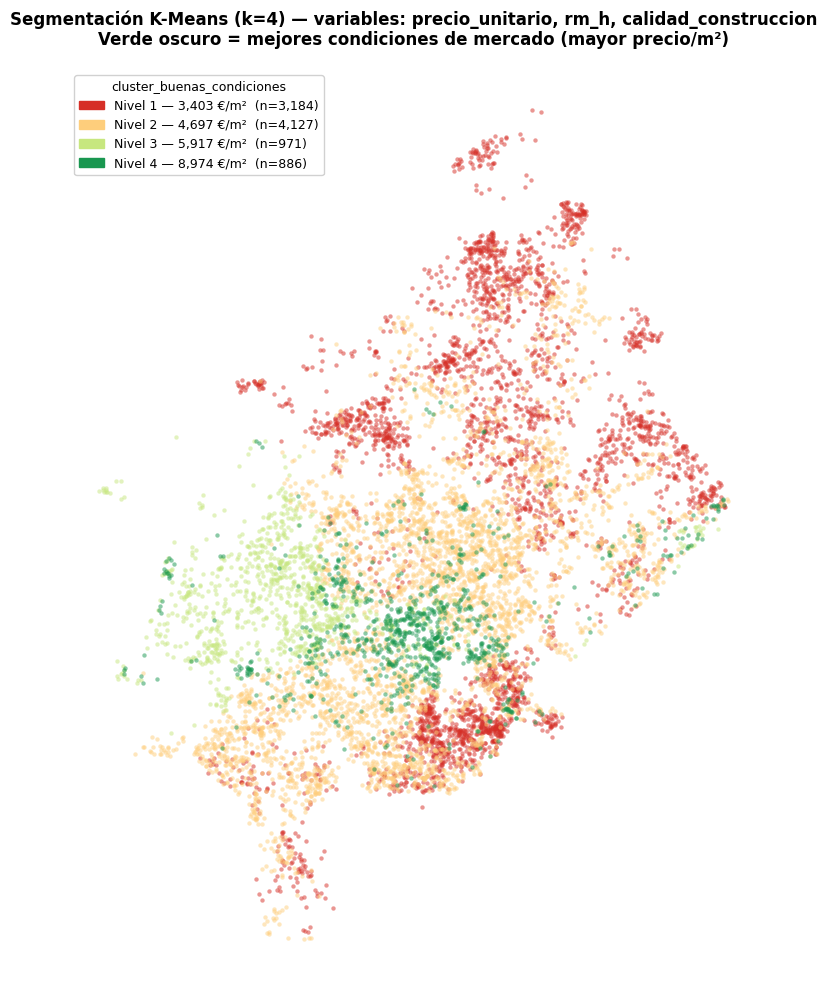

In [16]:
mapa_clusters_kmeans(
    gdf_km,
    col_cluster_ord='cluster_buenas_condiciones',
    mapa_etiqueta=mapa_etiqueta,
    precio_medio_por_cluster=precio_medio_por_cluster,
    k_optimo=K_OPTIMO,
    vars_kmeans=VARS_KMEANS
)


---
## Paso 4 — Exportar resultados a Google Drive

Guardamos un único GeoPackage con todas las variables nuevas generadas en este cuaderno:
- `indice_centralidad` (CP1 del PCA)
- `cluster` (etiqueta numérica original de K-Means)
- `cluster_buenas_condiciones` (etiqueta ordinal por precio)


In [17]:
# ✏️ MODIFICA AQUÍ — Ruta de salida en tu Google Drive
RUTA_SALIDA_C3 = "/content/drive/MyDrive/srgvua/datos_cuaderno3.gpkg"

# ─── Unir variables nuevas al dataset de ofertas ──────────────────────────────
# PCA: indice_centralidad ya está en gdf_ofertas
# K-Means: cluster y cluster_buenas_condiciones están en gdf_km

vars_km_export = gdf_km[['cluster', 'cluster_buenas_condiciones']].copy()

gdf_final = gdf_ofertas.merge(vars_km_export, left_index=True, right_index=True, how='left')

print(f"✅ Dataset final: {len(gdf_final):,} filas × {gdf_final.shape[1]} columnas")
print(f"   Columnas nuevas: indice_centralidad, cluster, cluster_buenas_condiciones")

# ─── Crear carpeta si no existe ───────────────────────────────────────────────
os.makedirs(os.path.dirname(RUTA_SALIDA_C3), exist_ok=True)

# ─── Guardar ─────────────────────────────────────────────────────────────────
gdf_final.to_file(RUTA_SALIDA_C3, driver='GPKG')
print(f"\n✅ GeoPackage guardado en Drive:")
print(f"   → {RUTA_SALIDA_C3}")

✅ Dataset final: 9,168 filas × 51 columnas
   Columnas nuevas: indice_centralidad, cluster, cluster_buenas_condiciones

✅ GeoPackage guardado en Drive:
   → /content/drive/MyDrive/srgvua/datos_cuaderno3.gpkg
